<a href="https://colab.research.google.com/github/Edenshmuel/CrimeData/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [1]:
import zipfile
import requests
from io import BytesIO
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Loading Supervised Datasets from GitHub Repository

In [2]:
# Define the ZIP file URL
zip_url = "https://github.com/Edenshmuel/CrimeData/raw/main/supervised_dataset.zip"

# Function to load a specific CSV file from the ZIP in GitHub
def load_csv_from_zip(zip_url, inner_file_name):
    response = requests.get(zip_url)
    if response.status_code == 200:
        with zipfile.ZipFile(BytesIO(response.content)) as z:
            with z.open(inner_file_name) as f:
                return pd.read_csv(f)
    else:
        raise Exception("Failed to download supervised_dataset.zip")

# Load datasets from the ZIP
X_train = load_csv_from_zip(zip_url, "X_train_supervised.csv")
X_test = load_csv_from_zip(zip_url, "X_test_supervised.csv")
y_train = load_csv_from_zip(zip_url, "y_train_supervised.csv").values.ravel()
y_test = load_csv_from_zip(zip_url, "y_test_supervised.csv").values.ravel()

Building and Training a Neural Network with Early Stopping and Learning Rate Reduction

In [3]:
# Define early stopping and learning rate reduction callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Build the neural network model
model = Sequential()

# Input layer with L2 regularization, LeakyReLU activation, and dropout
model.add(Dense(512, kernel_regularizer=l2(0.01), input_shape=(X_train.shape[1],)))
model.add(LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer 1
model.add(Dense(256, kernel_regularizer=l2(0.01)))
model.add(LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden layer 2
model.add(Dense(128, kernel_regularizer=l2(0.01)))
model.add(LeakyReLU(alpha=0.01))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Output layer with softmax activation for multi-class classification
model.add(Dense(len(np.unique(y_train)), activation='softmax'))

# Compile the model with Adam optimizer and sparse categorical cross-entropy
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with early stopping and learning rate reduction
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=512,
                    validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.3201 - loss: 2.7657 - val_accuracy: 0.3864 - val_loss: 1.5951 - learning_rate: 0.0010
Epoch 2/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3620 - loss: 1.6183 - val_accuracy: 0.3867 - val_loss: 1.5845 - learning_rate: 0.0010
Epoch 3/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3632 - loss: 1.6118 - val_accuracy: 0.0532 - val_loss: 2.2130 - learning_rate: 0.0010
Epoch 4/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3634 - loss: 1.6078 - val_accuracy: 0.0635 - val_loss: 2.3982 - learning_rate: 0.0010
Epoch 5/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3729 - loss: 1.5931 - val_accuracy: 0.0214 - val_loss: 10.1613 - learning_rate: 0.0010
Epoch 6/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3767 - loss: 1.5747 - val_accuracy: 0.0727 - val_loss: 2.3986 - learning_rate: 5.0000e-04
Epoch 7/50
2129/2129 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.3

Evaluating Model Performance on the Test Set

In [4]:
# Evaluate the model on the test set and print the accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

12651/12651 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.3426 - loss: 1.6307
Test Accuracy: 34.72%


Generating Predictions Using the Trained Model

In [5]:
# Predict class probabilities and convert them to class labels
y_pred_dnn = model.predict(X_test)
y_pred_dnn_classes = np.argmax(y_pred_dnn, axis=1)

12651/12651 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step


Evaluation Function for Classification Models

In [6]:
# Define a function to calculate and return multiple evaluation metrics
def evaluate_model(y_true, y_pred, average='weighted'):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average=average, zero_division=0),
        "Confusion Matrix": confusion_matrix(y_true, y_pred)
    }
    return metrics

Evaluating the DNN Model on the Test Set

In [7]:
dnn_metrics = evaluate_model(y_test, y_pred_dnn_classes)

for metric, value in dnn_metrics.items():
    print(f"DNN {metric}: {value}")

DNN Accuracy: 0.3472385878842225
DNN Precision: 0.23771869356910563
DNN Recall: 0.3472385878842225
DNN F1 Score: 0.22045754488708535
DNN Confusion Matrix: [[     0    208      0      0      0      0   6898      0      0      0
       0      0      0      0]
 [     0  11982      0      0      0      0 122725      0      0      0
       0      0      0      0]
 [     0     35      0      0      0      0    606      0      0      0
       0      0      0      0]
 [     0   6260      0      0      0      0  57477      0      0      0
       0      0      0      0]
 [     0    835      0      0      0      0   6818      0      0      0
       0      0      0      0]
 [     0   1556      0      0      0      0  22165      0      0      0
       0      0      0      0]
 [     0  10423      0      0      0      0 128584      0      0      0
       0      0      0      0]
 [     0   1568      0      0      0      0  18274      0      0      0
       0      0      0      0]
 [     0    318      

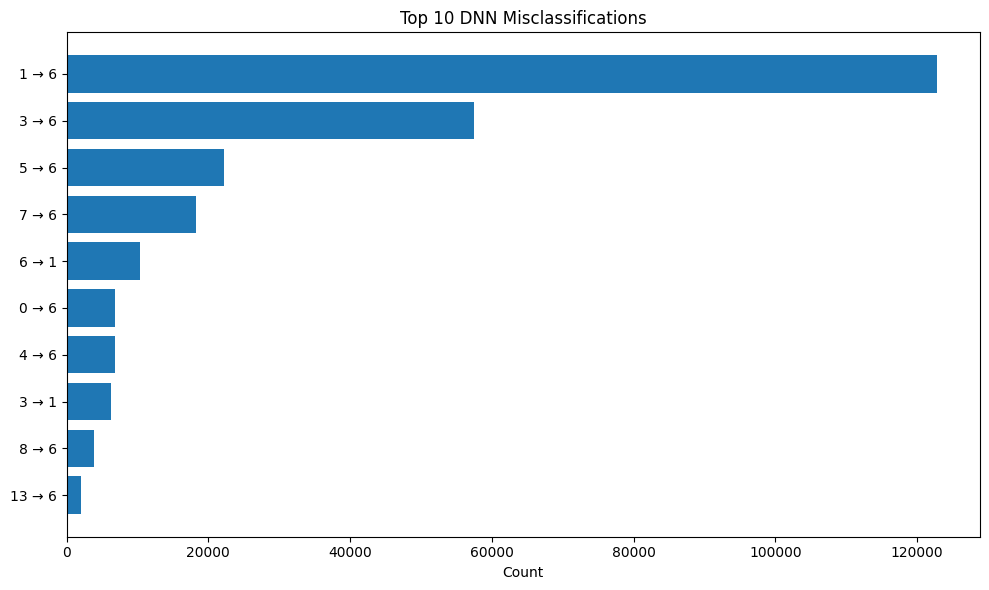

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dnn_classes, labels=np.unique(y_test))
labels = np.unique(y_test)

misclassified = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            misclassified.append((labels[i], labels[j], cm[i, j]))

misclassified_df = pd.DataFrame(
    misclassified, columns=["True Class", "Predicted Class", "Count"]
).sort_values("Count", ascending=False).head(10)

misclassified_df["Pair"] = (
    misclassified_df["True Class"].astype(str)
    + " → " +
    misclassified_df["Predicted Class"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(misclassified_df["Pair"], misclassified_df["Count"])
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Top 10 DNN Misclassifications")

plt.tight_layout()
plt.show()